In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


# *CONVERTING ALL THE FILES INTO A DATAFRAME
***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [3]:
file_paths=['/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', '/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv','/kaggle/input/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv', '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', '/kaggle/input/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv', '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv', '/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', '/kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv']
dfs=[]
for file in file_paths:
    df=pd.read_csv(file, low_memory=False)
    df=df.loc[:, ~df.columns.duplicated()]
    dfs.append(df)
combined_df=pd.concat(dfs, ignore_index=True)
combined_df=combined_df.loc[:, ~combined_df.columns.duplicated()]

# *CHECKING FOR THE SUCCESSFUL CREATION OF THE DATAFRAME***

In [4]:
combined_df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.97561,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.97561,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
del df

In [6]:
df=combined_df.copy()

In [7]:
df.shape

(2830743, 79)

In [8]:
df.columns=df.columns.str.strip()

In [9]:
df.tail(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830742,53,94939,4,2,188,226,47,47,47.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [10]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [12]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [13]:
numeric_df=df.select_dtypes(include=['int64', 'float64'])
cat_df=df.select_dtypes(include=['object'])

In [14]:
print(f"numerical columns in dataset : {numeric_df.columns}")
print(f"count of numerical columns in dataset : {len(numeric_df.columns)}")

numerical columns in dataset : Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN F

In [15]:
print(f"categorical columns in dataset: {cat_df.columns}")
print(f"count of categorical columns in dataset : {len(cat_df.columns)}")

categorical columns in dataset: Index(['Label'], dtype='object')
count of categorical columns in dataset : 1


In [16]:
def countmissing(data):
    miss_vals=data.isnull().sum()
    for col, val in miss_vals.items():
        if val!=0:
            print(f"column {col} has {val} missing values amounting to the {(val/len(data))*100 : .2f}% of total")

In [17]:
countmissing(df)

column Flow Bytes/s has 1358 missing values amounting to the  0.05% of total


In [18]:
df.dropna(inplace=True)

In [19]:
def countduplicate(data):
    duplicate_count=df.duplicated().sum()
    print(f" The number of the duplicated rows in the dataset is  {duplicate_count} amounting to the {(duplicate_count/len(data))*100 : .2f}% of total")

In [20]:
countduplicate(df)

 The number of the duplicated rows in the dataset is  307376 amounting to the  10.86% of total


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
print(f"Dataset dimension after removing duplicates : {df.shape}")

Dataset dimension after removing duplicates : (2522009, 79)


In [23]:
def duplicatecols(df):
    identical_cols={}
    visited=set()
    for i in range(len(df.columns)):
        col1=df.columns[i]
        for j in range(i+1, len(df.columns)):
            col2=df.columns[j]
            if col2 not in visited and df[col1].equals(df[col2]):
                if col1 not in identical_cols:
                    identical_cols[col1]=[col2]
                else:
                    identical_cols[col1].append(col2)
                visited.add(col2)
    return identical_cols

In [24]:
def drop_duplicate_cols(df, identical_cols):
    cols_to_drop = []
    for duplicates in identical_cols.values():
        cols_to_drop.extend(duplicates)
    df.drop(columns=cols_to_drop, inplace=True)
    return df

In [25]:
duplicate_cols=duplicatecols(df)

In [26]:
if duplicate_cols:
    for original, copy in duplicate_cols.items():
        print(f"the column [{original}] is same as {copy}")
else:
    print(f"there are no duplicate columns")

the column [Total Fwd Packets] is same as ['Subflow Fwd Packets']
the column [Total Backward Packets] is same as ['Subflow Bwd Packets']
the column [Fwd PSH Flags] is same as ['SYN Flag Count']
the column [Bwd PSH Flags] is same as ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
the column [Fwd URG Flags] is same as ['CWE Flag Count']
the column [Fwd Header Length] is same as ['Fwd Header Length.1']


In [27]:
df3=drop_duplicate_cols(df, duplicate_cols)

In [28]:
df3.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

In [29]:
df3.shape

(2522009, 67)

In [30]:
num_df=df3.select_dtypes(include=['int64', 'float64'])
num_cols=num_df.columns
inf_count=np.isinf(df3[num_cols]).sum()
print(inf_count[inf_count>0])

Flow Bytes/s      1211
Flow Packets/s    1211
dtype: int64


In [31]:
countmissing(df3)

In [32]:
df3.replace([np.inf, -np.inf], np.nan, inplace=True)

In [33]:
df3.dropna(inplace=True)

In [34]:
df3.shape

(2520798, 67)

In [35]:
del df

In [36]:
df=df3.copy()

In [37]:
df.shape

(2520798, 67)

In [38]:
for col in df.columns:
    if df[col].nunique()==1:
        print(f" {col} : {df[col].nunique()}")

 Bwd PSH Flags : 1


In [39]:
df.drop('Bwd PSH Flags',axis=1, inplace=True)

In [40]:
df.shape

(2520798, 66)

In [41]:
del num_df

In [42]:
del numeric_df

In [43]:
del cat_df

In [44]:
num_df=df.select_dtypes(include=['int64', 'float64'])

In [45]:
num_df.shape

(2520798, 65)

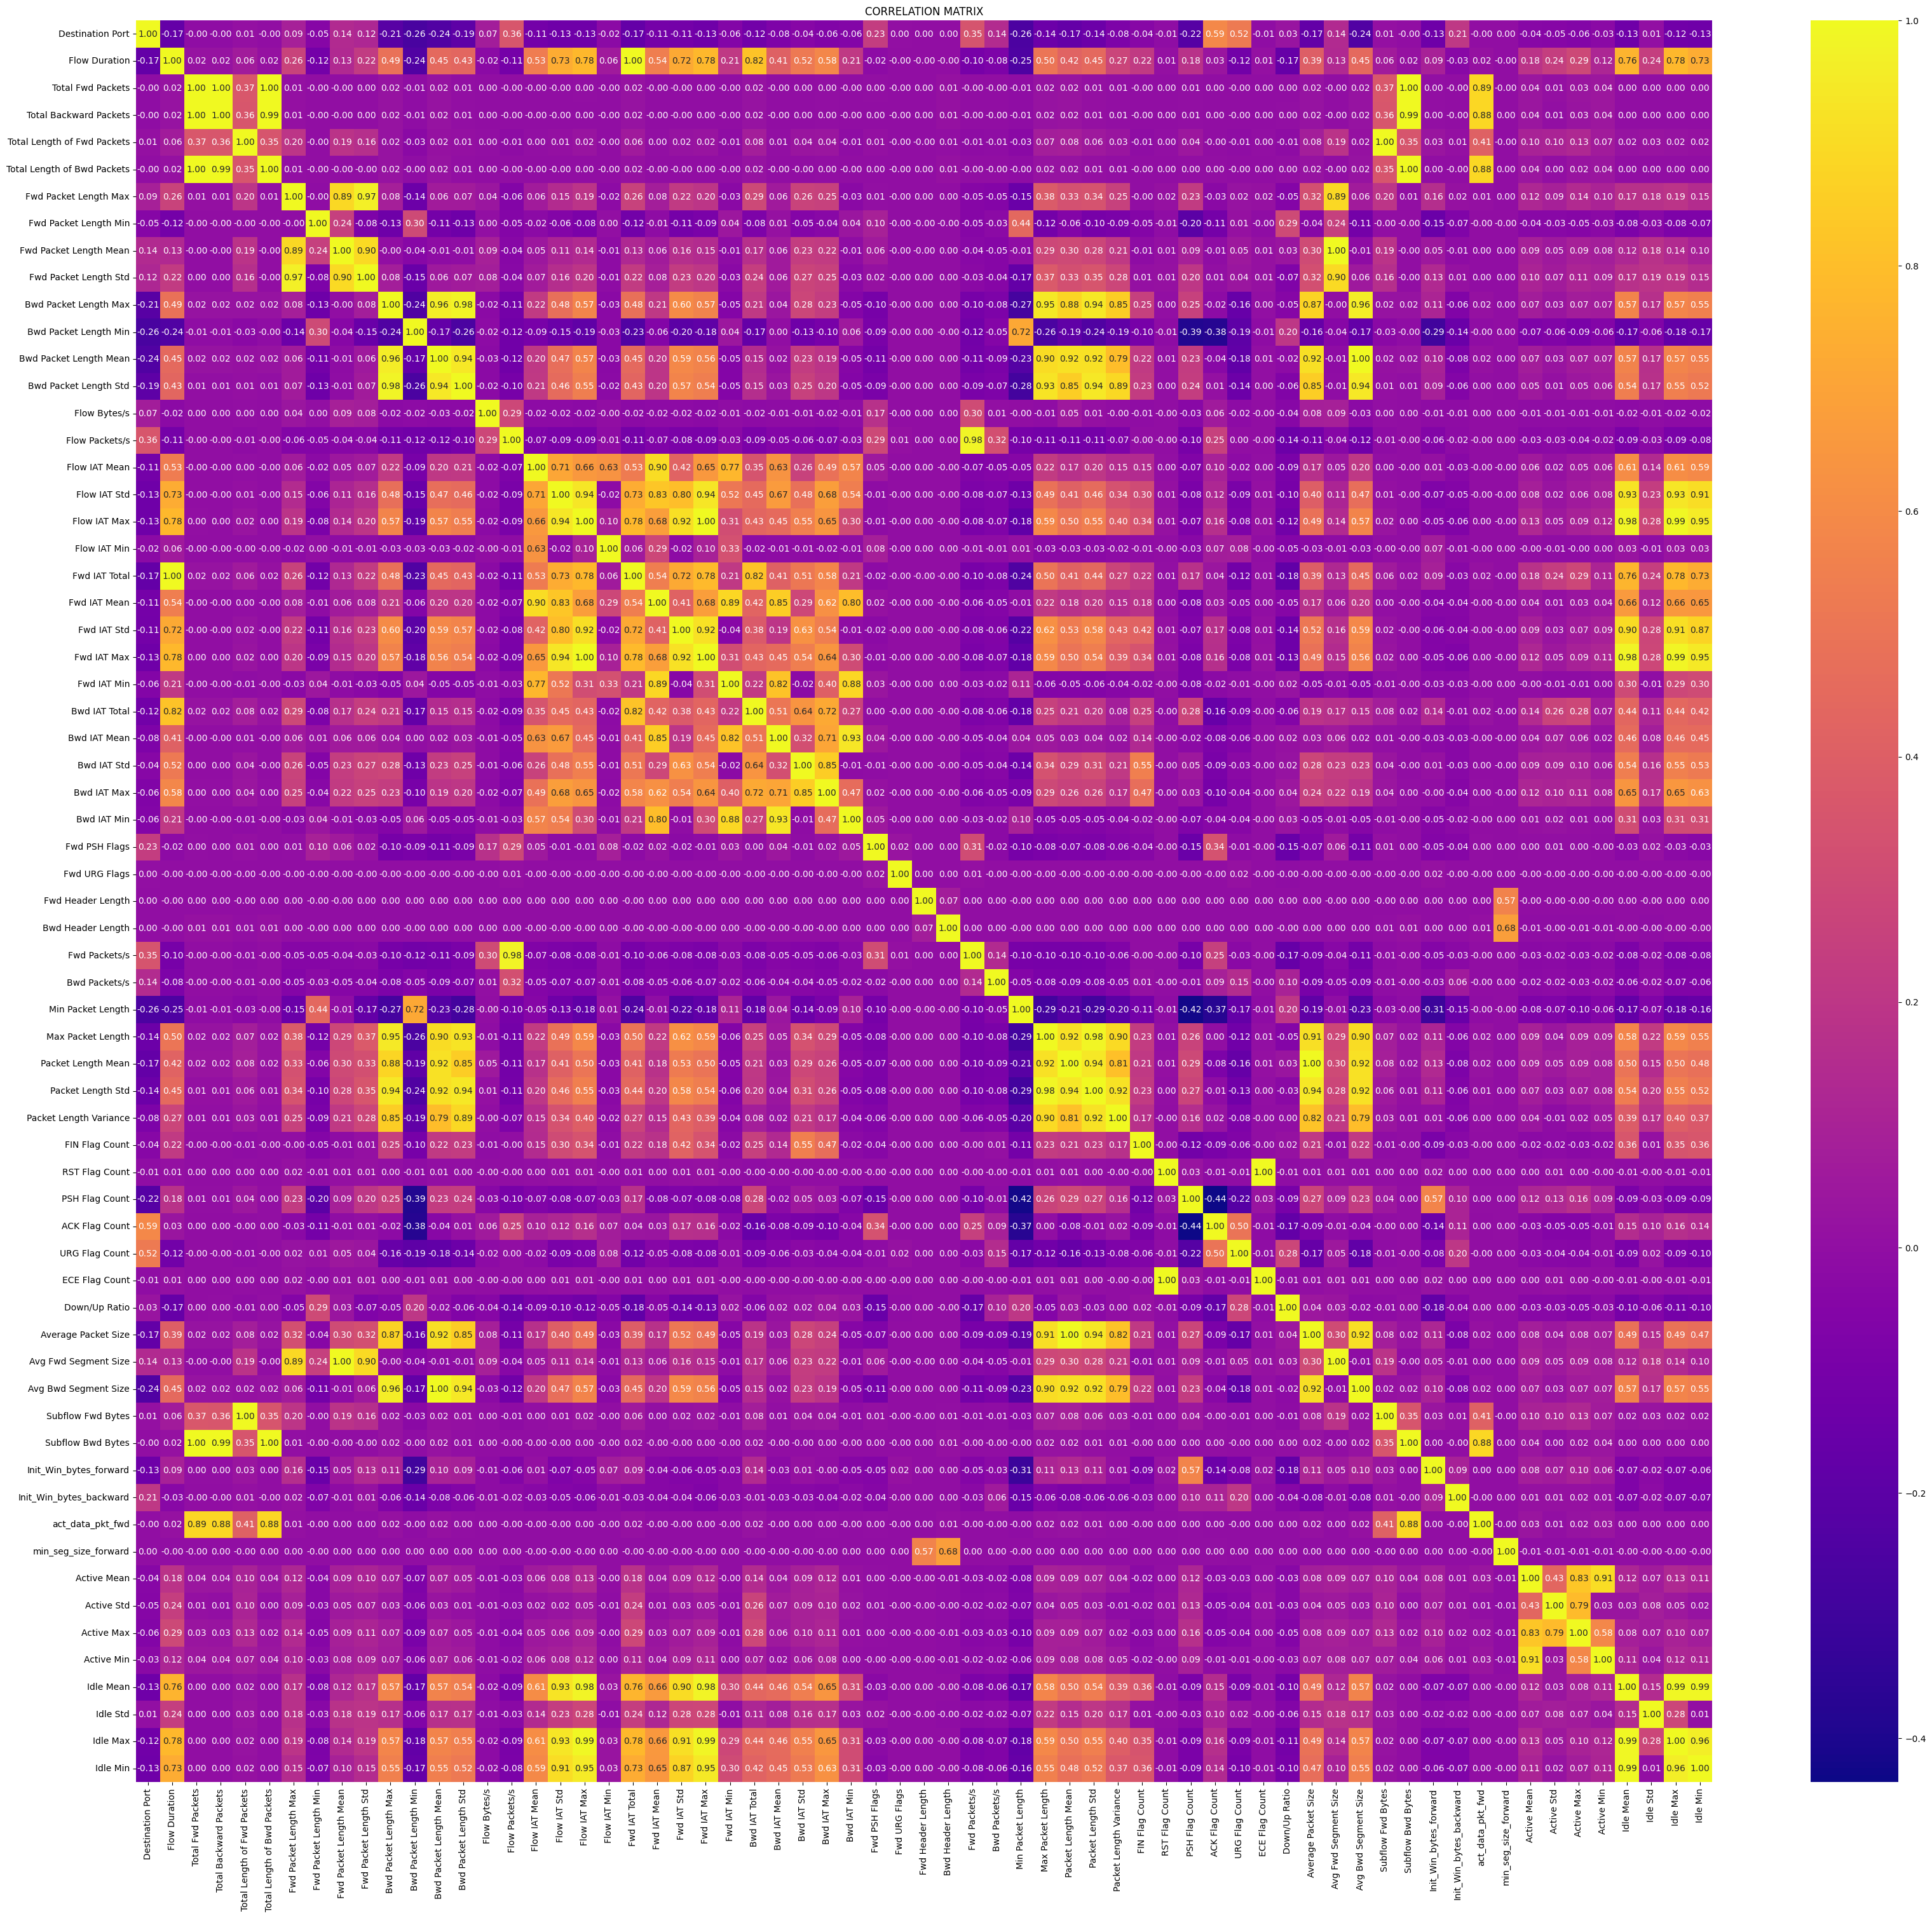

In [46]:
corr_matrix=num_df.corr()
plt.figure(figsize=(40,36))
sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt='.2f')
plt.title("CORRELATION MATRIX")
plt.show()

<Figure size 1400x1000 with 0 Axes>

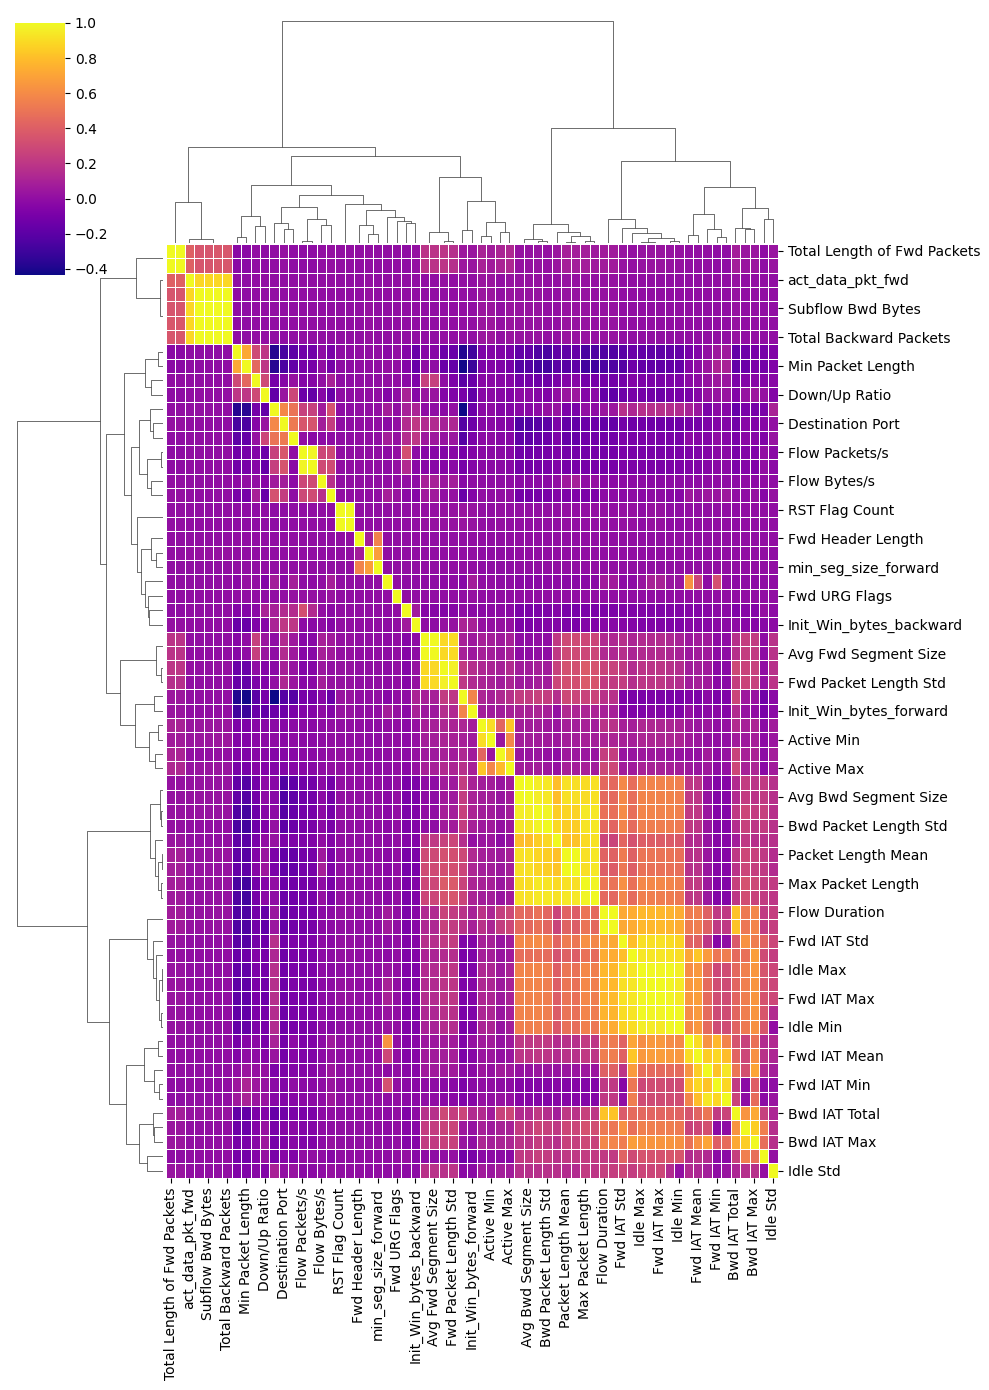

In [47]:
plt.figure(figsize=(14,10))
sns.clustermap(corr_matrix, method='ward', annot=False, cmap='plasma', linewidths=0.5, figsize=(10, 14))


In [48]:
corr_matrix = num_df.corr().abs()
correlation_threshold = 0.85
mask = np.triu(corr_matrix > correlation_threshold, k=1)
high_corr_features = [(corr_matrix.columns[i], corr_matrix.columns[j]) for i, j in zip(*np.where(mask))]

In [49]:
print(high_corr_features)

[('Flow Duration', 'Fwd IAT Total'), ('Total Fwd Packets', 'Total Backward Packets'), ('Total Fwd Packets', 'Total Length of Bwd Packets'), ('Total Fwd Packets', 'Subflow Bwd Bytes'), ('Total Fwd Packets', 'act_data_pkt_fwd'), ('Total Backward Packets', 'Total Length of Bwd Packets'), ('Total Backward Packets', 'Subflow Bwd Bytes'), ('Total Backward Packets', 'act_data_pkt_fwd'), ('Total Length of Fwd Packets', 'Subflow Fwd Bytes'), ('Total Length of Bwd Packets', 'Subflow Bwd Bytes'), ('Total Length of Bwd Packets', 'act_data_pkt_fwd'), ('Fwd Packet Length Max', 'Fwd Packet Length Mean'), ('Fwd Packet Length Max', 'Fwd Packet Length Std'), ('Fwd Packet Length Max', 'Avg Fwd Segment Size'), ('Fwd Packet Length Mean', 'Fwd Packet Length Std'), ('Fwd Packet Length Mean', 'Avg Fwd Segment Size'), ('Fwd Packet Length Std', 'Avg Fwd Segment Size'), ('Bwd Packet Length Max', 'Bwd Packet Length Mean'), ('Bwd Packet Length Max', 'Bwd Packet Length Std'), ('Bwd Packet Length Max', 'Max Packet L

In [50]:
distance_matrix = 1 - corr_matrix
linkage_matrix = linkage(squareform(distance_matrix), method='ward')

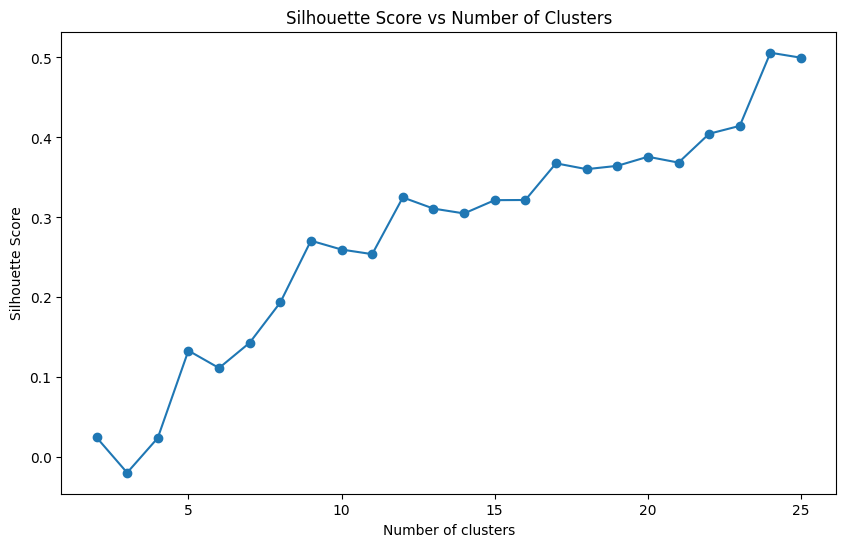

Optimal number of clusters: 24
Cluster 0: ['Active Mean', 'Active Std', 'Active Max', 'Active Min']
Cluster 1: ['PSH Flag Count', 'Init_Win_bytes_forward']
Cluster 2: ['Destination Port', 'ACK Flag Count', 'URG Flag Count']
Cluster 3: ['Flow Duration', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Total', 'Bwd IAT Std', 'Bwd IAT Max', 'Idle Mean', 'Idle Max', 'Idle Min']
Cluster 4: ['Flow Packets/s', 'Fwd Packets/s']
Cluster 5: ['Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size']
Cluster 6: ['Bwd Packet Length Min', 'Min Packet Length']
Cluster 7: ['Flow IAT Mean', 'Fwd IAT Mean', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Min']
Cluster 8: ['Bwd Header Length', 'min_seg_size_forward']
Cluster 9: ['Bwd Packets/s']
Cluster 10: ['Total Length of Fwd Packets', 'Subflow Fwd Bytes']
Cluster 11: 

In [51]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

from scipy.spatial.distance import squareform
condensed_distance = squareform(distance_matrix)

linkage_matrix = linkage(condensed_distance, method='ward')
clusters = fcluster(linkage_matrix, t=0.2, criterion='distance')

# Create feature groups
feature_clusters = pd.DataFrame({'Feature': corr_matrix.columns, 'Cluster': clusters})
clustered_features = feature_clusters.groupby('Cluster')['Feature'].apply(list)

n_clusters_range = range(2, 26)
silhouette_scores = []

for n_clusters in n_clusters_range:
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',  
        linkage='average'
    )
    cluster_labels = clusterer.fit_predict(distance_matrix)
    silhouette_avg = silhouette_score(distance_matrix, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot to find optimal clusters
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

# Get optimal number of clusters
optimal_k = n_clusters_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

# Apply clustering with optimal k
final_clusterer = AgglomerativeClustering(
    n_clusters=optimal_k,
    metric='precomputed',
    linkage='average'
)
optimal_clusters = final_clusterer.fit_predict(distance_matrix)

# Create feature groups with optimal clustering
optimal_feature_clusters = pd.DataFrame({
    'Feature': corr_matrix.columns, 
    'Cluster': optimal_clusters
})
optimal_clustered_features = optimal_feature_clusters.groupby('Cluster')['Feature'].apply(list)

# Print the clusters
for cluster_id, features in optimal_clustered_features.items():
    print(f"Cluster {cluster_id}: {features}")

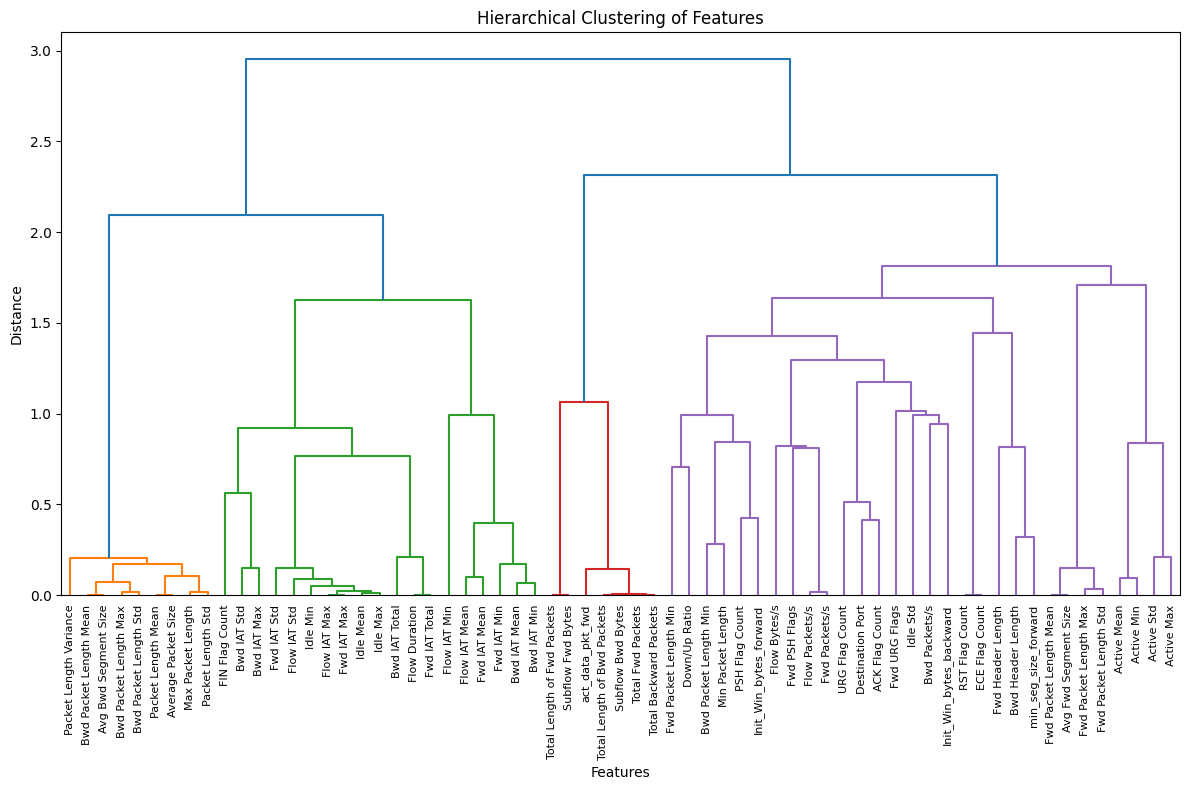

<Figure size 1400x1200 with 0 Axes>

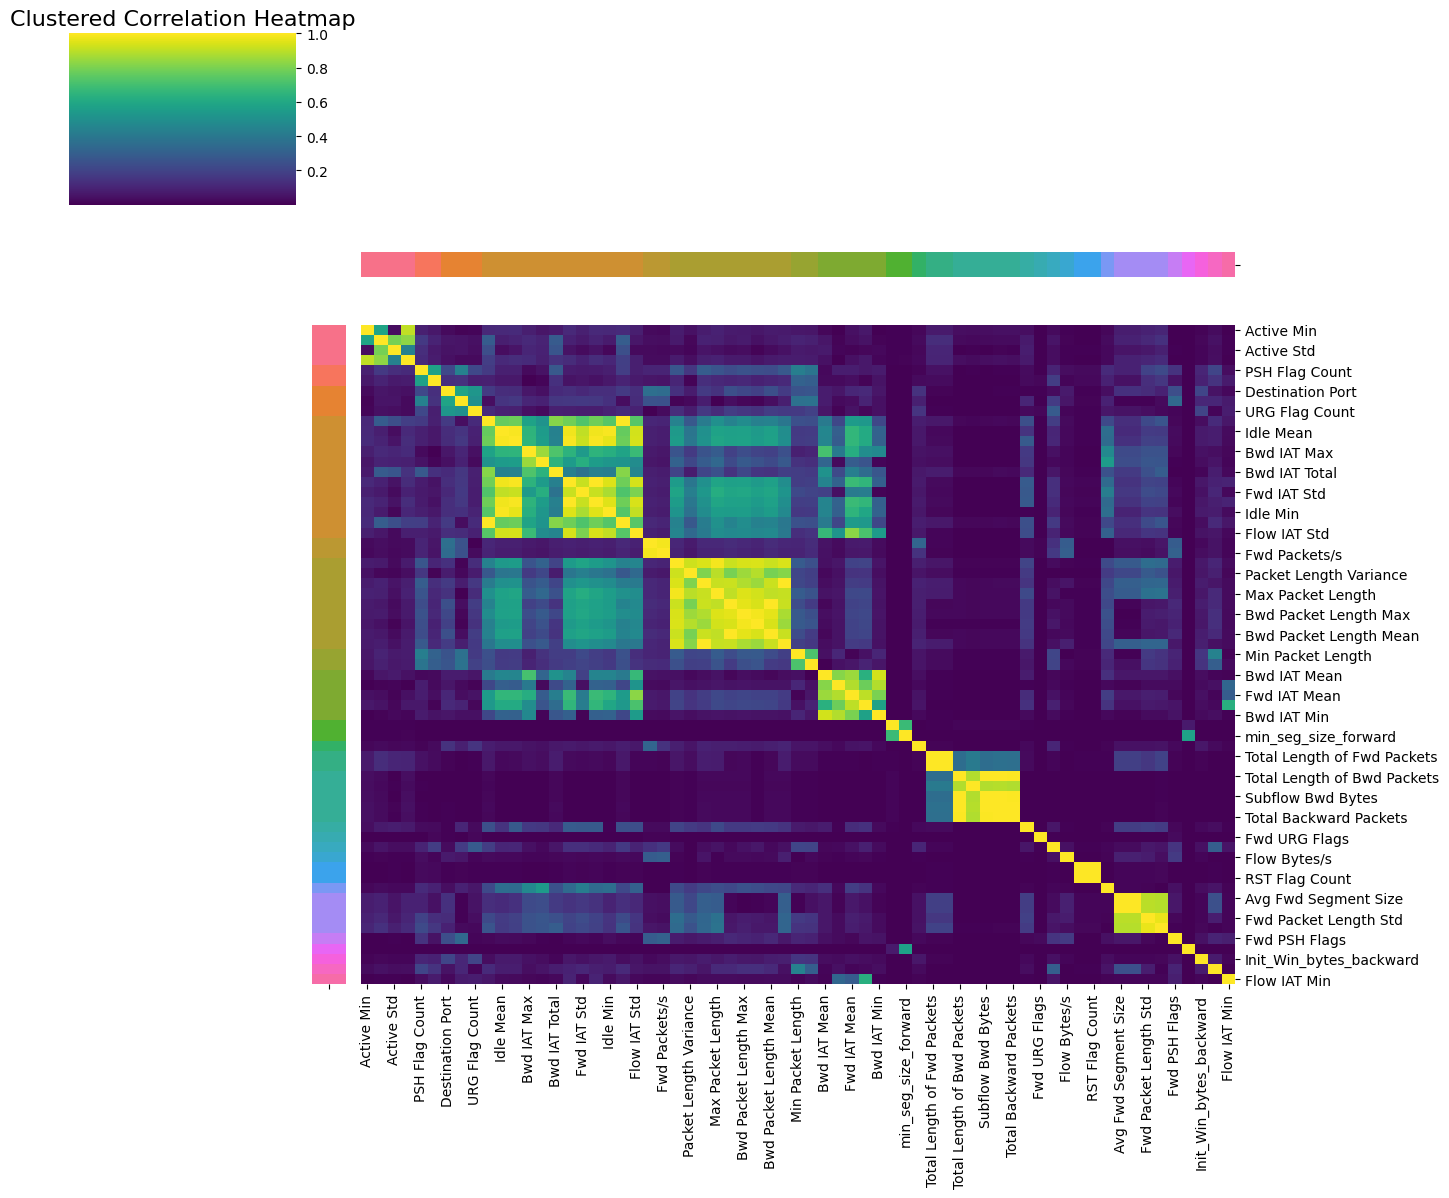

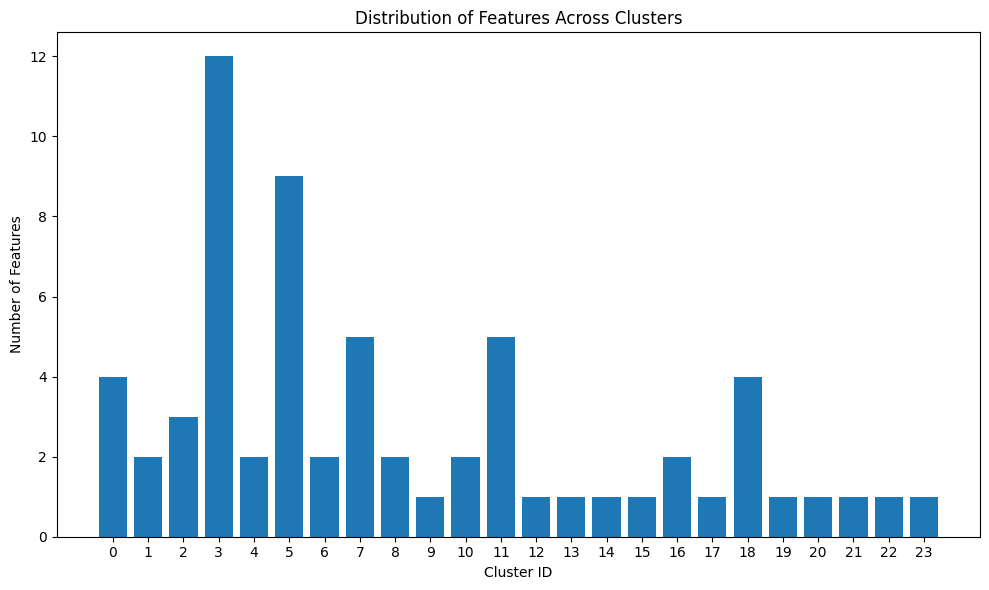

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


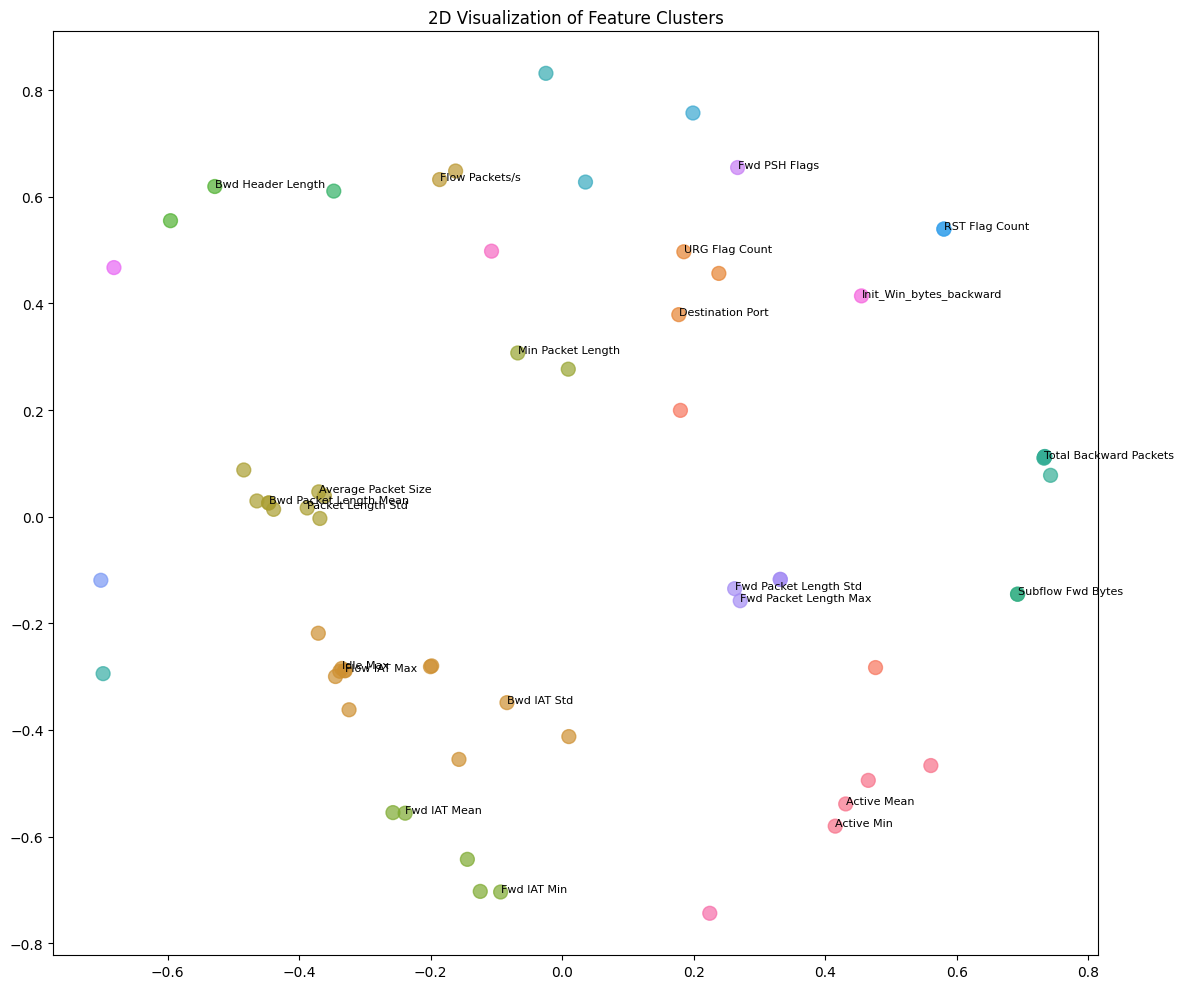

In [52]:
from scipy.cluster.hierarchy import dendrogram


# 1. Hierarchical Clustering Dendrogram
plt.figure(figsize=(12, 8))
plt.title('Hierarchical Clustering of Features')
plt.xlabel('Features')
plt.ylabel('Distance')

# Generate dendrogram
dendrogram(
    linkage_matrix,
    leaf_rotation=90.,  
    leaf_font_size=8.,  
    labels=corr_matrix.columns
)
plt.tight_layout()
plt.show()

optimal_feature_clusters_sorted = optimal_feature_clusters.sort_values('Cluster')
ordered_features = optimal_feature_clusters_sorted['Feature'].tolist()

ordered_corr = corr_matrix.loc[ordered_features, ordered_features]

cluster_ids = optimal_feature_clusters['Cluster'].unique()
cluster_colors = sns.color_palette("husl", n_colors=len(cluster_ids))

row_colors = []
for feature in ordered_features:
    cluster = optimal_feature_clusters.loc[optimal_feature_clusters['Feature'] == feature, 'Cluster'].values[0]
    row_colors.append(cluster_colors[cluster])

plt.figure(figsize=(14, 12))
g = sns.clustermap(
    ordered_corr,
    row_colors=pd.Series(row_colors, index=ordered_features),
    col_colors=pd.Series(row_colors, index=ordered_features),
    figsize=(14, 12),
    cmap="viridis",
    row_cluster=False, 
    col_cluster=False
)
plt.title('Clustered Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
cluster_counts = optimal_feature_clusters['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster ID')
plt.ylabel('Number of Features')
plt.title('Distribution of Features Across Clusters')
plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

# 2D Projection of Feature Space (using MDS)
from sklearn.manifold import MDS

# MDS (Multidimensional Scaling) to visualize in 2D
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
feature_positions = mds.fit_transform(distance_matrix)

plt.figure(figsize=(12, 10))

# Getting cluster for each feature
feature_to_cluster = dict(zip(optimal_feature_clusters['Feature'], optimal_feature_clusters['Cluster']))

#  colors list
colors = [cluster_colors[feature_to_cluster[feature]] for feature in corr_matrix.columns]

# Scatter plot
plt.scatter(
    feature_positions[:, 0], 
    feature_positions[:, 1], 
    c=colors, 
    s=100, 
    alpha=0.7
)

for i, feature in enumerate(corr_matrix.columns):
    # Only labelling some features to avoid overcrowding
    if i % 3 == 0:  # Labelling every 3rd feature for above reason
        plt.annotate(
            feature, 
            (feature_positions[i, 0], feature_positions[i, 1]),
            fontsize=8
        )

plt.title('2D Visualization of Feature Clusters')
plt.tight_layout()
plt.show()

In [53]:
df2=df.copy()

In [54]:
df2.shape

(2520798, 66)

In [55]:
from sklearn.decomposition import PCA
active_features = df2[['Active Mean', 'Active Std', 'Active Max', 'Active Min']]
pca = PCA(n_components=1)
df2['Active_Profile'] = pca.fit_transform(active_features)
print("Explained Variance Ratio for 'Active_Profile' composite feature:", pca.explained_variance_ratio_[0])


Explained Variance Ratio for 'Active_Profile' composite feature: 0.8266412466340066


In [56]:
features = df2[['Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']]
pca2 = PCA(n_components=1)
df2['Fwd Packet Length_Profile'] = pca2.fit_transform(features)
print("Explained Variance Ratio:", pca2.explained_variance_ratio_[0])

Explained Variance Ratio: 0.9826075754742573


In [57]:
features1 = df2[['Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Total Fwd Packets', 'Total Backward Packets']]
pca3 = PCA(n_components=1)
df2['Total Packets and Subflow Bwd Profile'] = pca3.fit_transform(features1)
print("Explained Variance Ratio:", pca3.explained_variance_ratio_[0])

Explained Variance Ratio: 0.9999999286576049


In [58]:
df2['Fwd Flow IAT Max']=(df2['Flow IAT Max']+df2['Fwd IAT Max'])/2

In [59]:
features2 = df2[['Idle Mean', 'Idle Max']]
pca4 = PCA(n_components=1)
df2['Idle Mean and Max Profile'] = pca4.fit_transform(features2)
print("Explained Variance Ratio:", pca4.explained_variance_ratio_[0])

Explained Variance Ratio: 0.9951229653754559


In [60]:
features3 = df2[['Fwd Flow IAT Max', 'Idle Mean and Max Profile']]
pca5 = PCA(n_components=1)
df2['Fwd Flow IAT Max and Idle Profile'] = pca5.fit_transform(features3)
print("Explained Variance Ratio:", pca5.explained_variance_ratio_[0])

Explained Variance Ratio: 0.9941862983439135


In [61]:
df2['Flow Duration Fwd IAT Total'] = np.where(df['Fwd IAT Total'] != 0,df['Flow Duration'] / df['Fwd IAT Total'],df['Flow Duration'])

In [62]:
features4 = df2[['Avg Fwd Segment Size', 'Fwd Packet Length Mean']]
pca6 = PCA(n_components=1)
df2['Fwd Avg Segement and Packet Length Mean profile'] = pca6.fit_transform(features4)
print("Explained Variance Ratio:", pca6.explained_variance_ratio_[0])

Explained Variance Ratio: 0.9999999999999977


In [63]:
features5 = df2[['Idle Mean', 'Idle Max', 'Idle Min']]
pca7 = PCA(n_components=1)
df2['Idle_Profile'] = pca7.fit_transform(features5)
print("Explained Variance Ratio:", pca7.explained_variance_ratio_[0])

Explained Variance Ratio: 0.9869644357724612


In [64]:
df.shape

(2520798, 66)

In [65]:
df2.shape

(2520798, 75)

In [66]:
to_drop=['Active Mean', 'Active Std', 'Active Max', 'Active Min','Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std','Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Total Fwd Packets', 'Total Backward Packets','Flow IAT Max','Fwd IAT Max','Idle Mean', 'Idle Max','Fwd Flow IAT Max', 'Idle Mean and Max Profile','Fwd IAT Total','Flow Duration','Avg Fwd Segment Size', 'Fwd Packet Length Mean','Idle Min']

In [67]:
print(len(to_drop))

22


In [68]:
df2.drop(to_drop, axis=1, inplace=True)

In [69]:
df2.shape

(2520798, 54)

In [70]:
dc=duplicatecols(df2)

In [71]:
if dc:
    print(dc)
else:
    print('no duplicate columns in df2')

no duplicate columns in df2


In [72]:
df2.columns

Index(['Destination Port', 'Total Length of Fwd Packets',
       'Fwd Packet Length Min', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count',
       'Down/Up Ratio', 'Average Packet Size', 'Avg Bwd Segment Size',
       'Subflow Fwd Bytes', 'Init_Win_bytes_forward',
       'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',


In [73]:
df2['Label'].value_counts()

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [74]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2520798 entries, 0 to 2830742
Data columns (total 54 columns):
 #   Column                                           Dtype  
---  ------                                           -----  
 0   Destination Port                                 int64  
 1   Total Length of Fwd Packets                      int64  
 2   Fwd Packet Length Min                            int64  
 3   Bwd Packet Length Max                            int64  
 4   Bwd Packet Length Min                            int64  
 5   Bwd Packet Length Mean                           float64
 6   Bwd Packet Length Std                            float64
 7   Flow Bytes/s                                     float64
 8   Flow Packets/s                                   float64
 9   Flow IAT Mean                                    float64
 10  Flow IAT Std                                     float64
 11  Flow IAT Min                                     int64  
 12  Fwd IAT Mean       

In [75]:
num_df=df2.select_dtypes(include=['int64', 'float64'])
categorical_df=df2.select_dtypes(include='object')

In [76]:
len(num_df.columns)

53

In [77]:
categorical_df.shape

(2520798, 1)

In [78]:
num_df.shape

(2520798, 53)

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance # since gpu is not available so we won't apply permutation importance but it is better criteria for getting feature importance  

X = df2.drop('Label', axis=1)
y = df2['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [80]:
print(rf_model.feature_importances_)

[2.66226188e-02 4.94973111e-02 2.58431802e-03 2.27742092e-02
 9.17823621e-03 3.53268540e-02 5.94238179e-02 1.97520867e-02
 1.42830707e-02 6.27057699e-03 2.30825060e-02 4.00396400e-03
 1.77582208e-02 2.88878581e-02 8.24283565e-03 4.78834178e-03
 5.48313246e-03 3.28313559e-03 3.74762875e-03 2.58517168e-03
 5.20742820e-04 1.16606079e-06 2.74316250e-02 1.91178020e-02
 8.89111107e-03 1.30161683e-02 5.36651980e-03 2.89039659e-02
 2.92742153e-02 7.44406751e-02 6.93679291e-02 4.53882864e-03
 0.00000000e+00 1.74298140e-02 1.01182529e-02 1.97560285e-03
 0.00000000e+00 8.50304982e-04 5.13646000e-02 4.35956512e-02
 4.58766324e-02 9.90560675e-03 1.70951471e-02 9.00213869e-03
 1.44823595e-02 8.52079871e-04 4.40864600e-03 3.20299593e-02
 5.15023485e-02 1.98602402e-02 4.89991365e-03 2.28666759e-02
 1.34373827e-02]


In [81]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

print(rf_importance)

                                            Feature  Importance
0                                  Destination Port    0.026623
1                       Total Length of Fwd Packets    0.049497
2                             Fwd Packet Length Min    0.002584
3                             Bwd Packet Length Max    0.022774
4                             Bwd Packet Length Min    0.009178
5                            Bwd Packet Length Mean    0.035327
6                             Bwd Packet Length Std    0.059424
7                                      Flow Bytes/s    0.019752
8                                    Flow Packets/s    0.014283
9                                     Flow IAT Mean    0.006271
10                                     Flow IAT Std    0.023083
11                                     Flow IAT Min    0.004004
12                                     Fwd IAT Mean    0.017758
13                                      Fwd IAT Std    0.028888
14                                      

In [82]:
rf_importance=rf_importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)

In [83]:
print(rf_importance)

                                            Feature  Importance
0                                 Packet Length Std    0.074441
1                            Packet Length Variance    0.069368
2                             Bwd Packet Length Std    0.059424
3             Total Packets and Subflow Bwd Profile    0.051502
4                               Average Packet Size    0.051365
5                       Total Length of Fwd Packets    0.049497
6                                 Subflow Fwd Bytes    0.045877
7                              Avg Bwd Segment Size    0.043596
8                            Bwd Packet Length Mean    0.035327
9                         Fwd Packet Length_Profile    0.032030
10                               Packet Length Mean    0.029274
11                                Max Packet Length    0.028904
12                                      Fwd IAT Std    0.028888
13                                Fwd Header Length    0.027432
14                                 Desti

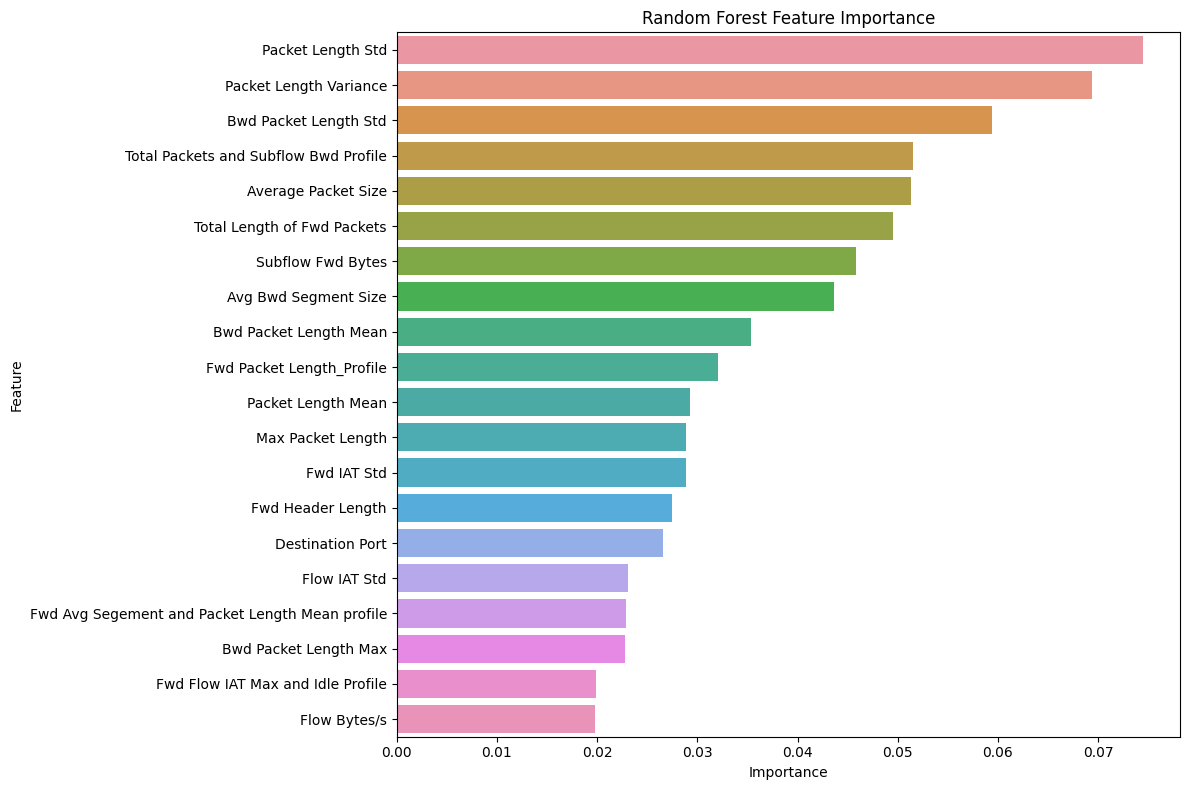

In [84]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(20))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [85]:
for col in num_df.columns:
    print(f"Skewness of {col} : {num_df[col].skew():.2f}")
#  since i have to apply tree-based models on the cleaned dataset, so i won't be treating the skewness of the data here

Skewness of Destination Port : 1.93
Skewness of Total Length of Fwd Packets : 760.58
Skewness of Fwd Packet Length Min : 19.33
Skewness of Bwd Packet Length Max : 2.73
Skewness of Bwd Packet Length Min : 4.78
Skewness of Bwd Packet Length Mean : 2.33
Skewness of Bwd Packet Length Std : 3.19
Skewness of Flow Bytes/s : 45.67
Skewness of Flow Packets/s : 6.94
Skewness of Flow IAT Mean : 8.50
Skewness of Flow IAT Std : 3.37
Skewness of Flow IAT Min : 23.48
Skewness of Fwd IAT Mean : 6.70
Skewness of Fwd IAT Std : 3.17
Skewness of Fwd IAT Min : 9.21
Skewness of Bwd IAT Total : 2.67
Skewness of Bwd IAT Mean : 7.78
Skewness of Bwd IAT Std : 5.44
Skewness of Bwd IAT Max : 4.15
Skewness of Bwd IAT Min : 9.35
Skewness of Fwd PSH Flags : 4.20
Skewness of Fwd URG Flags : 177.50
Skewness of Fwd Header Length : -1250.43
Skewness of Bwd Header Length : -676.64
Skewness of Fwd Packets/s : 7.27
Skewness of Bwd Packets/s : 21.71
Skewness of Min Packet Length : 10.55
Skewness of Max Packet Length : 2.61


In [86]:
def detect_outliers_iqr(df, num_df):
    outlier_stats = []
    for col in num_df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        
        outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        total_count = df[col].count()
        percentage = (outlier_count / total_count) * 100

        outlier_stats.append({
            'Column': col,
            'Outlier Count': outlier_count,
            'Total Count': total_count,
            'Outlier %': round(percentage, 2)
        })

    return pd.DataFrame(outlier_stats).sort_values(by='Outlier %', ascending=False)


outlier_summary = detect_outliers_iqr(df2, num_df)
print(outlier_summary)


                                             Column  Outlier Count  \
13                                      Fwd IAT Std         596378   
25                                    Bwd Packets/s         589916   
49                Fwd Flow IAT Max and Idle Profile         577358   
48            Total Packets and Subflow Bwd Profile         575459   
52                                     Idle_Profile         567236   
50                      Flow Duration Fwd IAT Total         566724   
46                                   Active_Profile         558827   
0                                  Destination Port         545620   
15                                    Bwd IAT Total         527554   
16                                     Bwd IAT Mean         519369   
14                                      Fwd IAT Min         513405   
18                                      Bwd IAT Max         508905   
12                                     Fwd IAT Mean         507354   
9                   

In [ ]:
import numpy as np
import pandas as pd

def treat_outliers(df, feature_importance_df, outlier_summary_df):
    # Convert feature importance to Series for easier access
    importance_series = pd.Series(
        feature_importance_df['Importance'].values, 
        index=feature_importance_df['Feature']
    )

    # Determine top 30% as high, bottom 20% as low importance
    sorted_features = importance_series.sort_values(ascending=False)
    num_features = len(sorted_features)
    high_importance = set(sorted_features.head(int(num_features * 0.30)).index)
    low_importance = set(sorted_features.tail(int(num_features * 0.20)).index)

    # Loop through outlier info
    for _, row in outlier_summary_df.iterrows():
        col = row['Column']
        outlier_pct = row['Outlier %']

        if col not in df.columns or col not in importance_series:
            continue

        importance = importance_series[col]
        if col in high_importance:
            importance_level = "high"
        elif col in low_importance:
            importance_level = "low"
        else:
            importance_level = "medium"
        if outlier_pct > 10:
            if importance_level == "high":
                df[col] = np.log1p(df[col].clip(lower=0))
            elif importance_level == "medium":
                df[col] = df[col].clip(upper=np.percentile(df[col], 95))
            else:
                df[col] = np.clip(df[col], df[col].quantile(0.05), df[col].quantile(0.95))
                if importance < 0.01:
                    df.drop(columns=[col], inplace=True)

        elif 5 < outlier_pct <= 10:
            if importance_level == "high":
                df[col] = np.sqrt(df[col].clip(lower=0))
            elif importance_level == "medium":
                df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
            else:
                df[col] = df[col].clip(upper=np.percentile(df[col], 95))

        elif 1 < outlier_pct <= 5:
            if importance_level == "high":
                pass  # Keep as-is
            elif importance_level == "medium":
                df[col] = df[col].clip(upper=np.percentile(df[col], 99))
            else:
                df[col] = df[col].mask(df[col] > df[col].quantile(0.99), df[col].median())

        else:  # outlier_pct ≤ 1
            if importance_level == "low" and importance < 0.005:
                df.drop(columns=[col], inplace=True)

    return df


In [92]:
def treat_outliers(df, feature_importance_df, outlier_summary_df):
    df_processed = df.copy()
    
    # Convert feature importance to Series
    l = list()  # List to track dropped features
    importance_series = pd.Series(
        feature_importance_df['Importance'].values, 
        index=feature_importance_df['Feature']
    )
    sorted_importance = importance_series.sort_values(ascending=False)
    high_cutoff = int(len(sorted_importance) * 0.30)
    low_cutoff = int(len(sorted_importance) * 0.80)  # bottom 20 of the features are being considered as low importance features
    
    high_importance = set(sorted_importance.iloc[:high_cutoff].index)
    low_importance = set(sorted_importance.iloc[low_cutoff:].index)
    common_features = set(importance_series.index) & set(outlier_summary_df['Column']) & set(df_processed.columns)
    outlier_info = {row['Column']: row['Outlier %'] for _, row in outlier_summary_df.iterrows() 
                    if row['Column'] in common_features}
    
    for col in common_features:
        outlier_pct = outlier_info[col]
        importance = importance_series[col]
        if col in high_importance:
            importance_level = "high"
        elif col in low_importance:
            importance_level = "low"
        else:
            importance_level = "medium"
        
        # Treatment logic based on outlier percentage and importance
        if outlier_pct > 10:
            if importance_level == "high":
                df_processed[col] = np.log1p(df_processed[col].clip(lower=0))
            elif importance_level == "medium":
                df_processed[col] = df_processed[col].clip(upper=np.percentile(df_processed[col], 95))
            elif importance < 0.005:
                l.append(col)
                df_processed.drop(columns=[col], inplace=True)
            else: 
                df_processed[col] = np.clip(df_processed[col], 
                                          df_processed[col].quantile(0.05), 
                                          df_processed[col].quantile(0.95))
        elif outlier_pct > 5:
            if importance_level == "high":
                df_processed[col] = np.sqrt(df_processed[col].clip(lower=0))
            elif importance_level == "medium":
                df_processed[col] = df_processed[col].clip(
                    df_processed[col].quantile(0.01), 
                    df_processed[col].quantile(0.99))
            else:
                df_processed[col] = df_processed[col].clip(upper=np.percentile(df_processed[col], 95))
        elif outlier_pct > 1:
            if importance_level == "high":
                pass  # Keep as-is,
            elif importance_level == "medium":
                df_processed[col] = df_processed[col].clip(upper=np.percentile(df_processed[col], 99))
            else:
                df_processed[col] = df_processed[col].mask(
                    df_processed[col] > df_processed[col].quantile(0.99), 
                    df_processed[col].median())
        elif importance_level == "low" and importance < 0.005:  # outlier_pct ≤ 1
            l.append(col)
            df_processed.drop(columns=[col], inplace=True)
    
    return df_processed, l

In [94]:
final_df, dropped_columns=treat_outliers(df2, rf_importance,outlier_summary)

In [95]:
final_df.shape

(2520798, 46)

In [96]:
print(len(dropped_columns))

8


In [97]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2520798 entries, 0 to 2830742
Data columns (total 46 columns):
 #   Column                                           Dtype  
---  ------                                           -----  
 0   Destination Port                                 float64
 1   Total Length of Fwd Packets                      float64
 2   Bwd Packet Length Max                            int64  
 3   Bwd Packet Length Min                            int64  
 4   Bwd Packet Length Mean                           float64
 5   Bwd Packet Length Std                            float64
 6   Flow Bytes/s                                     float64
 7   Flow Packets/s                                   float64
 8   Flow IAT Mean                                    float64
 9   Flow IAT Std                                     float64
 10  Flow IAT Min                                     int64  
 11  Fwd IAT Mean                                     float64
 12  Fwd IAT Std        

In [98]:
final_df.to_csv("final_df.csv", index=False)

*DONE*****